<a href="https://colab.research.google.com/github/Vibhu-Maurya/DeepLearning2025-26/blob/main/CNNTraffic_Light_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

json_path = "/content/drive/MyDrive/archive/train_dataset/train.json"

with open(json_path) as f:
    data = json.load(f)

print(data.keys())
print(data["annotations"][0])

dict_keys(['annotations'])
{'filename': 'train_images\\00001.jpg', 'bndbox': {'xmin': 1026.5, 'ymin': 741.8, 'xmax': 1077.5, 'ymax': 910.9}, 'inbox': [{'color': 'red', 'shape': '0', 'bndbox': {'xmin': 1037.2, 'ymin': 750.8, 'xmax': 1068.6, 'ymax': 800.3}, 'occluded': 0, 'truncated': 0, 'difficult': 0, 'value': -1}], 'truncated': 0, 'occluded': 0, 'ignore': 0}


In [ ]:
import json
import cv2
import os

json_path = "/content/drive/MyDrive/archive/train_dataset/train.json"
image_folder = "/content/drive/MyDrive/archive/train_dataset/train_images"
output_folder = "/content/traffic_classification"

classes = ["red", "yellow", "green"]
for cls in classes:
    os.makedirs(os.path.join(output_folder, cls), exist_ok=True)

with open(json_path) as f:
    data = json.load(f)

count = 0

for item in data["annotations"]:

    img_name = item["filename"].split("\\")[-1]
    img_path = os.path.join(image_folder, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    # Loop inside inbox
    for obj in item["inbox"]:

        color = obj["color"]

        if color not in classes:
            continue

        box = obj["bndbox"]

        xmin = int(box["xmin"])
        ymin = int(box["ymin"])
        xmax = int(box["xmax"])
        ymax = int(box["ymax"])

        cropped = img[ymin:ymax, xmin:xmax]

        save_path = os.path.join(output_folder, color, f"{count}.jpg")
        cv2.imwrite(save_path, cropped)

        count += 1

print("✅ Conversion completed successfully!")

✅ Conversion completed successfully!


In [ ]:
import os

print("Red:", len(os.listdir("/content/traffic_classification/red")))
print("Yellow:", len(os.listdir("/content/traffic_classification/yellow")))
print("Green:", len(os.listdir("/content/traffic_classification/green")))

Red: 5361
Yellow: 171
Green: 3890


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator (NO augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/traffic_classification",
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    "/content/traffic_classification",
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🔥 CRITICAL
)

Found 7538 images belonging to 3 classes.
Found 1884 images belonging to 3 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.8074121679520138), 1: np.float64(0.5858397450843242), 2: np.float64(18.340632603406327)}


In [ ]:
print(train_data.class_indices)

{'green': 0, 'red': 1, 'yellow': 2}


In [ ]:
class_weights = {
    0: 1.0,   # green
    1: 1.0,   # red
    2: 4.0    # yellow
}

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(64,64,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8355 - loss: 0.3869 - val_accuracy: 0.9268 - val_loss: 0.2227
Epoch 2/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8355 - loss: 0.3962 - val_accuracy: 0.9092 - val_loss: 0.2737
Epoch 3/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.8416 - loss: 0.3979 - val_accuracy: 0.9061 - val_loss: 0.2912
Epoch 4/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.8914 - loss: 0.3134 - val_accuracy: 0.8482 - val_loss: 0.4101
Epoch 5/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.8874 - loss: 0.3186 - val_accuracy: 0.8848 - val_loss: 0.4053
Epoch 6/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8936 - loss: 0.3003 - val_accuracy: 0.8551 - val_loss: 0.3931
Epoch 7/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.9122 - loss: 0.2516 - val_accuracy: 0.9464 - val_loss: 0.2117
Epoch 8/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.9168 - loss: 0.2717 - 

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

val_data.reset()
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

print(classification_report(val_data.classes, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       778
           1       0.97      0.94      0.96      1072
           2       0.34      0.85      0.48        34

    accuracy                           0.95      1884
   macro avg       0.76      0.92      0.80      1884
weighted avg       0.96      0.95      0.95      1884



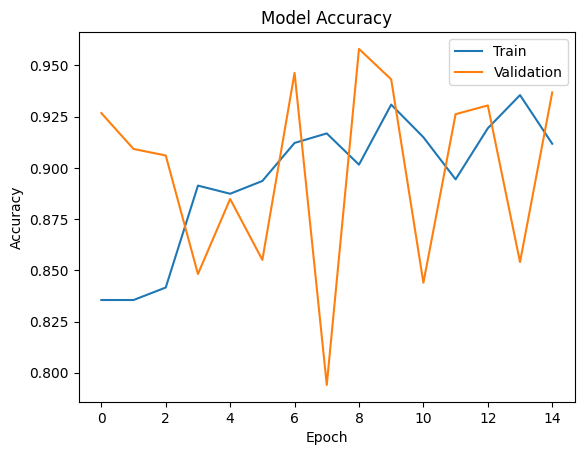

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

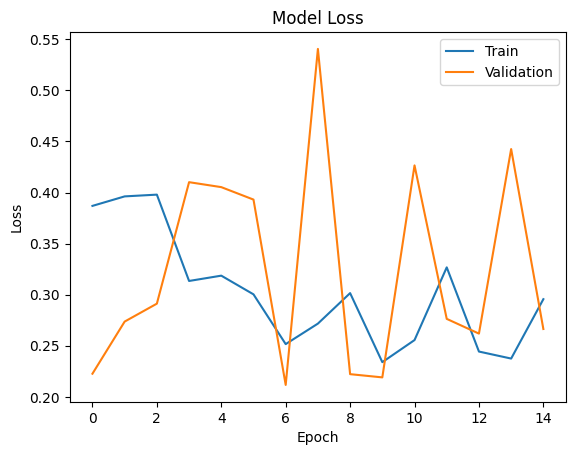

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

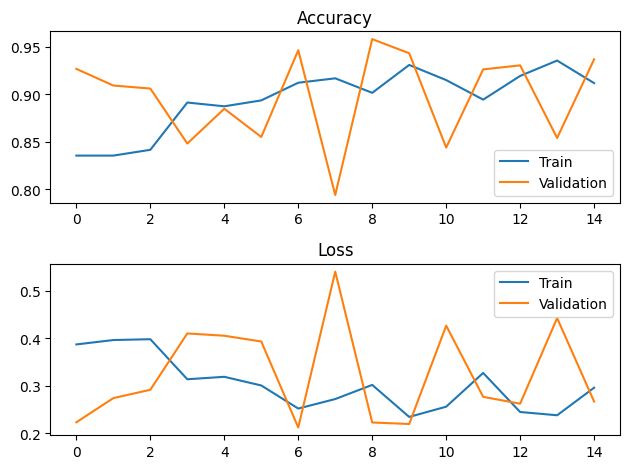

In [ ]:
fig, ax = plt.subplots(2, 1)

# Accuracy
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Accuracy')
ax[0].legend(['Train', 'Validation'])

# Loss
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Loss')
ax[1].legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


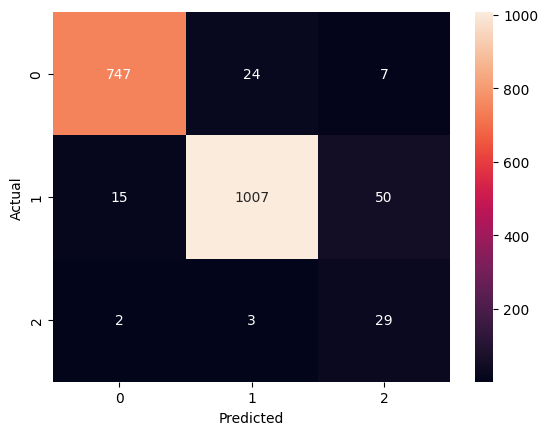

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

val_data.reset()
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

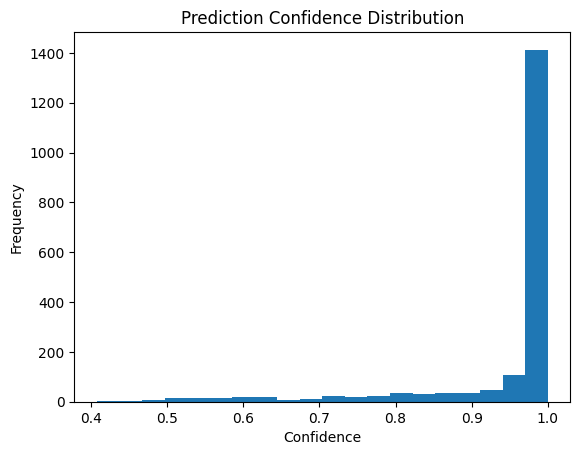

In [ ]:
plt.figure()
plt.hist(np.max(pred, axis=1), bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save("/content/drive/MyDrive/traffic_light_cnn.h5")

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/traffic_light_cnn.h5"))

True


# **testing**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/traffic_light_cnn.h5")

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving test2.jpg to test2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: green


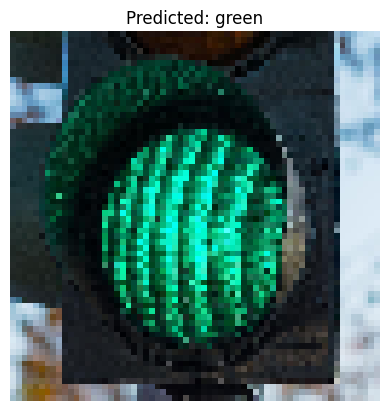

In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "test2.jpg"   # change name

img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0);

prediction = model.predict(img_array)
class_index = np.argmax(prediction)

# Define class_labels explicitly as train_data is not available in this scope
class_labels = ['green', 'red', 'yellow']

print("Prediction:", class_labels[class_index])

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {class_labels[class_index]}")
plt.show()

In [6]:
for i, prob in enumerate(prediction[0]):
    print(f"{class_labels[i]}: {prob*100:.2f}%")

green: 100.00%
red: 0.00%
yellow: 0.00%


# **Frontend**

In [7]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 120.8 MB/s eta 0:00:00


In [8]:
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# Load model
model = load_model("/content/drive/MyDrive/traffic_light_cnn.h5")

class_labels = ['green', 'red', 'yellow']

# Title
st.title("🚦 Traffic Light Detection System")

# Upload image
uploaded_file = st.file_uploader("Upload an Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded Image", use_column_width=True)

    # Preprocess
    img = img.resize((64,64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)

    result = class_labels[class_index]

    # Output
    if result == "red":
        st.error("🔴 STOP")
    elif result == "green":
        st.success("🟢 GO")
    else:
        st.warning("🟡 WAIT")

    st.write("### Confidence:")
    for i, prob in enumerate(prediction[0]):
        st.write(f"{class_labels[i]}: {prob*100:.2f}%")

2026-04-15 16:08:39.651 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.727 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-15 16:08:40.731 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 16:08:40.741 Thread 'MainThread': mi

In [9]:
!pip install streamlit pyngrok
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [10]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

model = load_model("/content/drive/MyDrive/traffic_light_cnn.h5")

class_labels = ['green', 'red', 'yellow']

st.title("🚦 Traffic Light Detection")

uploaded_file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded Image")

    img = img.resize((64,64))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)

    st.success(f"Prediction: {class_labels[class_index]}")

Writing app.py


In [14]:
!curl ipv4.icanhazip.com

34.186.27.179


In [15]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧your url is: https://three-insects-build.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.27.179:8501

2026-04-15 16:22:29.916982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776270149.940594    9250 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776270149.948287    9250 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776270149.966591    9250 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776270149.966638 